In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os
import glob
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import astropy
from astropy.io import fits
import astropy.wcs
from astropy import units as u

%matplotlib inline

In [3]:
import pickle

In [4]:
from reproject import reproject_interp
from reproject.mosaicking import reproject_and_coadd
from reproject.mosaicking import find_optimal_celestial_wcs


In [5]:
from matplotlib.patches import ConnectionPatch


In [6]:
def get_imgarr(fitsfile, idx=0, return_header=False):
    """get image array from fits
    Parameters:
        fitsfile: FITS file
        idx: hdul index in FITS
        return_header: boolean, return FITS header
    """
    from astropy.io import fits
    hdul = fits.open(fitsfile)
    item = hdul[idx]
    if item.is_image:
        header = item.header
        # invert y to be same as jpg
        #imgarr = item.data[::-1, :] 
        imgarr = item.data
        hdul.close()
        if return_header:
            return imgarr, header
        else:
            return imgarr
    else:
        print('not image file')
    
def get_vmin_vmax(img, low=5, high=95):
    """return the percentile value at low and high"""
    img_nonan = img[~np.isnan(img)]
    vmin = np.percentile(img_nonan, low)
    vmax = np.percentile(img_nonan, high)
    return vmin, vmax


In [7]:

def add_circle(xc, yc, r, ax):
    """
    add circle patch to axis
    xc, yc, radius in data unit
    """
    #xc = 2000
    #yc = 4000
    
    circle = matplotlib.patches.Circle(xy=(xc, yc), radius=r, 
                                       color='r', linewidth=.5, fill=False)
        
    ax.add_patch(circle)
    return ax

    # remove a patch
    #ax.patches[2].remove()

### load light curve data

In [121]:
# Load the variable back
with open('ec0915i_poly1.pkl', 'rb') as file:
    dic_df_poly1 = pickle.load(file)


In [122]:
# Load the variable back
with open('ec0915i_54_2.pkl', 'rb') as file:
    dic_df_poly2 = pickle.load(file)


In [123]:
# Load the variable back
with open('ec0915i_57_poly1.pkl', 'rb') as file:
    dic_df_57 = pickle.load(file)


In [124]:
with open('ec0915i_54_Arm.pkl', 'rb') as file:
    dic_df_54_Arm = pickle.load(file)


In [125]:
IDs_good_fits_poly1 = [12, 13, 17, 18, 19, 25, 26, 27, 31, 35, 36, 37, 38, 
                      59, 61, 62, 63, 64, 72, 73, 74, 75, 77, 88, 90, 
                      105, 106, 137, 190, 191, 950, 952, 999, 998, 996, ]

IDs_good_fits_57 = [ 119, 120, 135, 137, 152, 155]


IDs_comet_poly1 = [1321, 1322, 1371, 1372, 1421, 1422, ]


IDs_54_Arm = [0, 1, 2, 3]


In [127]:
dic_df_poly1[19].columns

Index(['ID', 'x', 'y', 'bsize', 'mjd', 'zpt', 'fluxADU', 'flux_err', 'X2norm',
       'Npix', 'Nmask', 'Jyas2', 'Jyas2_err', 'SB', 'SB_err', 'skip', 'imID',
       'filter', 'CONVOL00', 'PHOTNORM', 'KSUM00', 'FSIG00', 'FSCAT00', 'FWHM',
       'M5SIGMA', 'SKYADU', 'good'],
      dtype='object')

### view all image

In [312]:
fits54 = glob.glob("./ec0915_data/ec0915/54/*_ooi_i*")
fits54.sort()

In [313]:
fits54_diff = glob.glob("./ec0915_data/ec0915_tmpl/54/*523435_ooi_i_*.fits")
fits54_diff.sort()

In [334]:
fitsfile.split('/')[-1]

'ec0915.130218.178843_ooi_i_N22.sw.fits'

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216


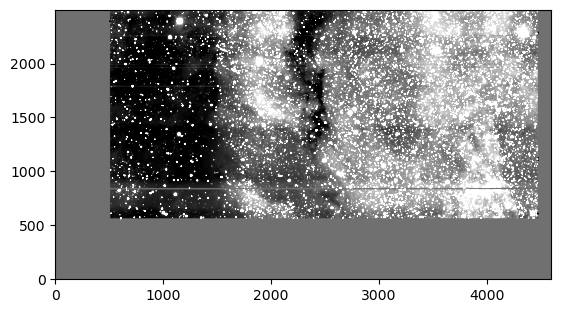

In [336]:
fig = plt.figure()
ax1 = fig.add_subplot(1, 1, 1, )# projection=wcs_out)


for i in range(len(fits54)):

    fitsfile = fits54[i]
    
    img54, header54= get_imgarr(fitsfile=fitsfile, 
                            idx=0, return_header=True)
    
    
    vmin, vmax = get_vmin_vmax(img54)

    
    ax1.imshow(img54, vmin=vmin, vmax=vmax, cmap='gray', origin='lower',)

    fname = fitsfile.split('/')[-1]
    fig.savefig(f'fits_image/i_band/{fname}.png', dpi=100,)
    print(i)


In [338]:
fitsfile.split('/')[-1]

'ec0915.130218.178843_ooi_i_N22_160305.523435_ooi_i_v1_N22.diff.fits'

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214


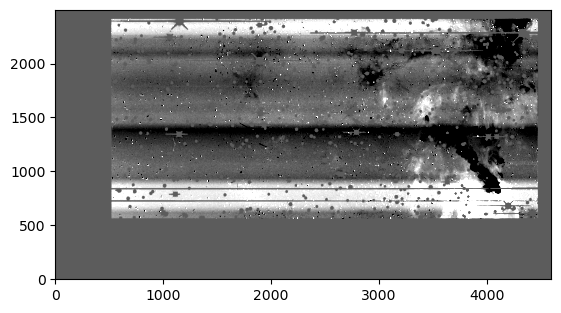

In [339]:
fig = plt.figure()
ax1 = fig.add_subplot(1, 1, 1, )# projection=wcs_out)


for i in range(len(fits54_diff)):

    fitsfile = fits54_diff[i]
    
    img54, header54= get_imgarr(fitsfile=fitsfile, 
                            idx=0, return_header=True)
    
    
    vmin, vmax = get_vmin_vmax(img54)

    
    ax1.imshow(img54, vmin=vmin, vmax=vmax, cmap='gray', origin='lower',)

    fname = fitsfile.split('/')[-1]
    fig.savefig(f'fits_image/i_band_diff/{fname}.png', dpi=100,)
    print(i)


bad image list

In [349]:
badimgs = ['ec0915.211114.1051159_ooi_i_v1_N22.sw.fits',
 'ec0915.211119.1053346_ooi_i_v1_N22.sw.fits',
 'ec0915.211210.1058364_ooi_i_v1_N22.sw.fits',
 'ec0915.211216.1062143_ooi_i_v1_N22.sw.fits',
 'ec0915.211219.1063439_ooi_i_v1_N22.sw.fits',
 'ec0915.211222.1064950_ooi_i_v1_N22.sw.fits',
 'ec0915.211231.1068343_ooi_i_v1_N22.sw.fits',
 'ec0915.220109.1070415_ooi_i_v1_N22.sw.fits',
 'ec0915.220116.1072685_ooi_i_v1_N22.sw.fits',
 'ec0915.220118.1073328_ooi_i_v1_N22.sw.fits',
 'ec0915.220121.1074494_ooi_i_v1_N22.sw.fits',
 'ec0915.220123.1075209_ooi_i_v1_N22.sw.fits',
 'ec0915.220224.1083413_ooi_i_v1_N22.sw.fits',
 'ec0915.220224.1083413_ooi_i_v2_N22.sw.fits',
 'ec0915.220304.1085354_ooi_i_v1_N22.sw.fits',
 'ec0915.220310.1086705_ooi_i_v1_N22.sw.fits',
 'ec0915.220420.1087190_ooi_i_v1_N22.sw.fits',
 'ec0915.220508.1093189_ooi_i_v1_N22.sw.fits',
 #'ec0915.220511.1094434_ooi_i_v1_N22.sw.fits',
 'ec0915.220607.1102551_ooi_i_v1_N22.sw.fits',
 #'ec0915.220613.1105609_ooi_i_v1_N22.sw.fits',
 'ec0915.220630.1111159_ooi_i_v1_N22.sw.fits',
 'ec0915.220730.1115459_ooi_i_v1_N22.sw.fits',
 'ec0915.220802.1116931_ooi_i_v1_N22.sw.fits',
 'ec0915.220807.1118055_ooi_i_v1_N22.sw.fits',
 'ec0915.221110.1149500_ooi_i_v1_N22.sw.fits',
 'ec0915.221116.1150875_ooi_i_v1_N22.sw.fits',
 'ec0915.221216.1156439_ooi_i_v1_N22.sw.fits',
 'ec0915.221231.1161160_ooi_i_v1_N22.sw.fits',
 'ec0915.230110.1164230_ooi_i_v1_N22.sw.fits',
 'ec0915.230202.1169866_ooi_i_v1_N22.sw.fits',
 'ec0915.230205.1170748_ooi_i_v1_N22.sw.fits',
 'ec0915.230211.1173624_ooi_i_v1_N22.sw.fits',
 'ec0915.230226.1177499_ooi_i_v1_N22.sw.fits',
 'ec0915.230305.1180038_ooi_i_v1_N22.sw.fits',
 'ec0915.230307.1180646_ooi_i_v1_N22.sw.fits',
 #'ec0915.230325.1187266_ooi_i_v1_N22.sw.fits',
 'ec0915.230331.1189511_ooi_i_v1_N22.sw.fits',
 'ec0915.230408.1191555_ooi_i_v1_N22.sw.fits',
 'ec0915.230427.1198564_ooi_i_v1_N22.sw.fits',
 'ec0915.230430.1199865_ooi_i_v1_N22.sw.fits',
 'ec0915.230512.1201908_ooi_i_v1_N22.sw.fits',
 'ec0915.230530.1208151_ooi_i_v1_N22.sw.fits',
 'ec0915.230605.1209986_ooi_i_v1_N22.sw.fits',
 'ec0915.230701.1217856_ooi_i_v1_N22.sw.fits',
 #'ec0915.230725.1224837_ooi_i_v1_N22.sw.fits',
 #'ec0915.230728.1225918_ooi_i_v1_N22.sw.fits',
 'ec0915.230801.1227844_ooi_i_v1_N22.sw.fits',
 'ec0915.231101.1251192_ooi_i_v1_N22.sw.fits',
 'ec0915.231105.1252383_ooi_i_v1_N22.sw.fits',
 'ec0915.231108.1253249_ooi_i_v1_N22.sw.fits',
 'ec0915.231117.1255249_ooi_i_v1_N22.sw.fits',
 'ec0915.231202.1256691_ooi_i_v1_N22.sw.fits',
 'ec0915.231220.1260835_ooi_i_v1_N22.sw.fits',
 'ec0915.231227.1262436_ooi_i_v1_N22.sw.fits',
 'ec0915.240113.1267287_ooi_i_v1_N22.sw.fits']



### load image data

In [13]:
fits54 = "EtaCar/ec0915a5457_images/54/ec0915.190222.826208_ooi_i_v1_N22_140329.296582_ooi_i_v1_N22.diff.fits"
img54, header54= get_imgarr(fitsfile=fits54, 
                        idx=0, return_header=True)


In [14]:
fits57 = "EtaCar/ec0915a5457_images/57/2023/ec0915.230226.1177499_ooi_i_v1_N26_150128.403910_ooi_i_v1_N26.diff.fits"
img57, header57= get_imgarr(fitsfile=fits57, 
                        idx=0, return_header=True)


In [15]:
w54 = astropy.wcs.WCS(header54)
w57 = astropy.wcs.WCS(header57)

w54.pixel_to_world(0, 0)

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (161.64191568, -60.37100605)>

In [ ]:
# Open both FITS files
hdu1 = fits.open(fits54)[0]
hdu2 = fits.open(fits57)[0]


# List of input HDUs
input_hdus = [(hdu1.data, hdu1.header), (hdu2.data, hdu2.header)]

wcs_out, shape_out = find_optimal_celestial_wcs(input_hdus)

## Reproject image2 to image1's WCS and shape
#array, footprint = reproject_interp(hdu2, hdu1.header)

# Define output WCS and shape automatically
# 'reproject_and_coadd' will create a combined WCS covering both images
array, footprint = reproject_and_coadd(
    input_hdus,
    wcs_out,    # Can use one image as reference OR auto-generate (see below)
    reproject_function=reproject_interp, shape_out=shape_out,
    combine_function='mean',  # or 'sum', 'median'
)



In [ ]:
dic_df_54_Arm[2].iloc[0][['ID', 'x', 'y']]

In [25]:
wcs_out

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 161.13556258157467 -60.35702407289284 
CRPIX : 3344.7275631198954 2311.779695684442 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -7.500000298e-05 7.500000298e-05 
NAXIS : 0  0

In [21]:
# 54 ID19
wcs_out.world_to_pixel( w54.pixel_to_world(4116, 816) )

(array(4120.02949108), array(2937.36346789))

In [22]:

# 57 ID135
wcs_out.world_to_pixel( w57.pixel_to_world(2046, 2331) )

(array(4134.05118624), array(2337.14077292))

In [23]:
# 54 comet

wcs_out.world_to_pixel( w54.pixel_to_world(3441, 1506) )

(array(3443.3864469), array(3625.74984981))

In [24]:
# 54 Armin
wcs_out.world_to_pixel( w54.pixel_to_world(3899, 1358) )


(array(3901.73758756), array(3478.84337858))

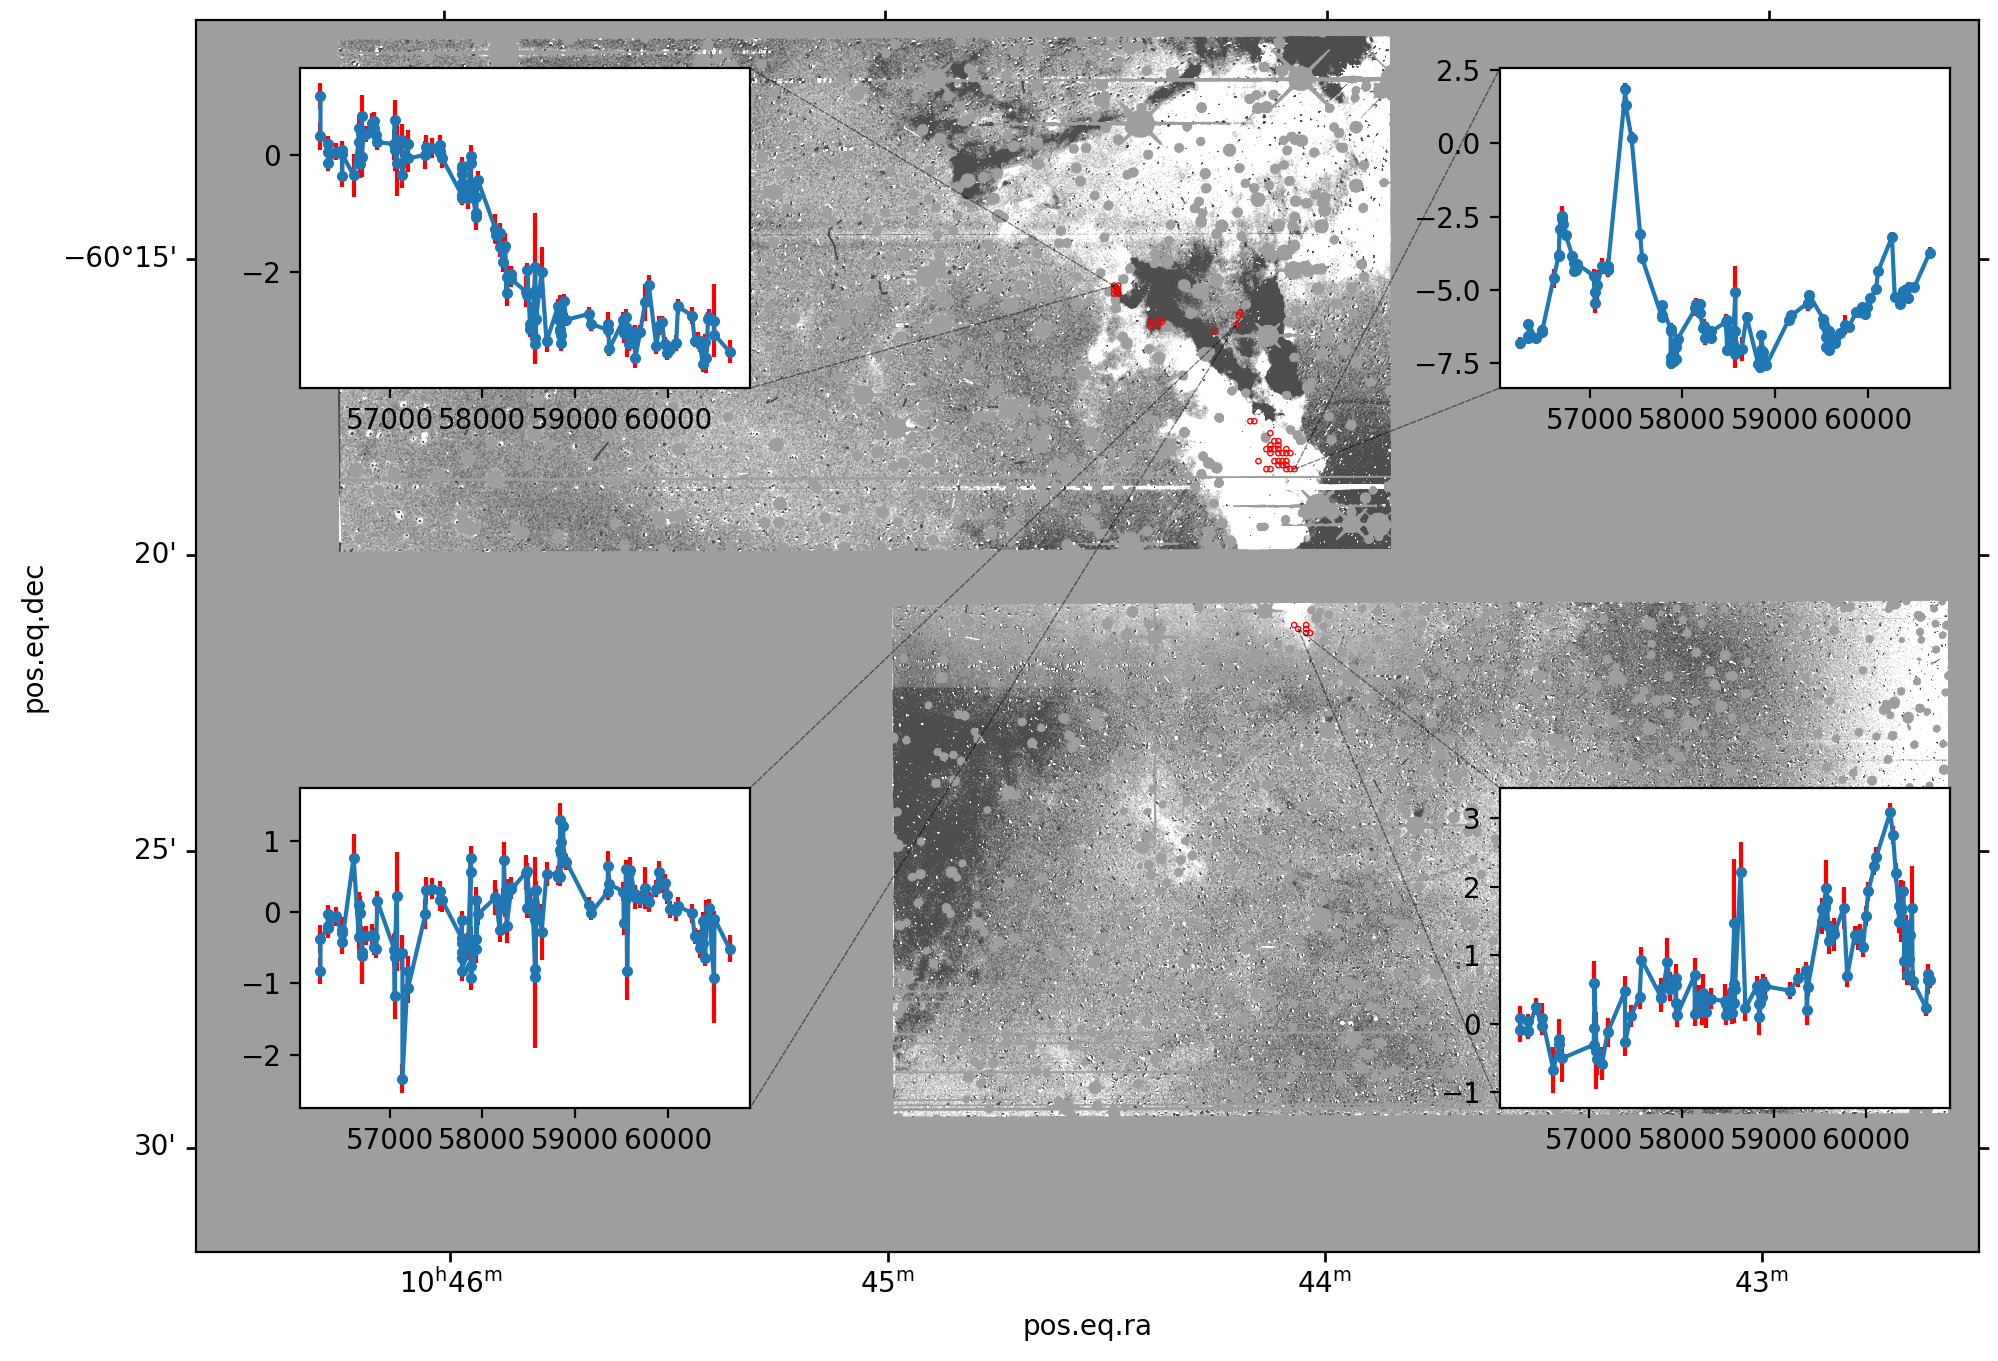

In [26]:
img = array
vmin, vmax = get_vmin_vmax(img)


fig = plt.figure(figsize=(15, 8))
ax1 = fig.add_subplot(1, 1, 1, projection=wcs_out)

ax1.imshow(img, vmin=vmin, vmax=vmax, 
                cmap='gray', origin='lower', alpha=0.7)


# -----------------------------------------------------
# 54 main

#add_circle(xc=4120, yc=2937, r=50, ax=ax1)

# [left, bottom, width, height] ratio relative to the figure
axin = fig.add_axes([0.65, 0.65, 0.15, 0.2])

df = dic_df_poly1[19]
idx = ( df.good ) & (df['fluxADU']<1000)
t = df[idx]['mjd'].values
f = df[idx]['Jyas2'].values
f_err = df[idx]['Jyas2_err'].values

axin.errorbar(t, f, f_err, fmt='.-', ecolor='red',)

## add connect line

con1 = ConnectionPatch(xyA=(4120, 2937), coordsA=ax1.transData,
                       xyB=(0, 0), coordsB=axin.transAxes,
                       color="k", ls='--', lw=.5, alpha=.5)
## upper-right corner to inset upper-right
con2 = ConnectionPatch(xyA=(4120, 2937), coordsA=ax1.transData,
                       xyB=(0, 1), coordsB=axin.transAxes,
                       color="k", ls='--', lw=.5, alpha=.5)

fig.add_artist(con1)
fig.add_artist(con2)

# ------------------------------------------------------------
# 57
#add_circle(xc=4134, yc=2337, r=50, ax=ax1)

# [left, bottom, width, height] ratio relative to the figure
axin = fig.add_axes([0.65, 0.2, 0.15, 0.2])

df = dic_df_57[137]
idx = ( df.good ) & (df['fluxADU']<1000)
t = df[idx]['mjd'].values
f = df[idx]['Jyas2'].values
f_err = df[idx]['Jyas2_err'].values

axin.errorbar(t, f, f_err, fmt='.-', ecolor='red',)

## add connect line

con1 = ConnectionPatch(xyA=(4134, 2337), coordsA=ax1.transData,
                       xyB=(0, 0), coordsB=axin.transAxes, 
                       color="k", ls='--', lw=.5, alpha=.5)
## upper-right corner to inset upper-right
con2 = ConnectionPatch(xyA=(4134, 2337), coordsA=ax1.transData,
                       xyB=(0, 1), coordsB=axin.transAxes, 
                       color="k", ls='--', lw=.5, alpha=.5)

fig.add_artist(con1)
fig.add_artist(con2)

# ------------------------------------------------------------

# comet

# 3443, 3625
#add_circle(xc=3443, yc=3625, r=50, ax=ax1)

# [left, bottom, width, height] ratio relative to the figure
axin = fig.add_axes([0.25, 0.65, 0.15, 0.2])

df = dic_df_poly1[1421]
idx = ( df.good ) & (df['fluxADU']<1000)
t = df[idx]['mjd'].values
f = df[idx]['Jyas2'].values
f_err = df[idx]['Jyas2_err'].values

axin.errorbar(t, f, f_err, fmt='.-', ecolor='red',)

## add connect line

con1 = ConnectionPatch(xyA=(3443, 3625), coordsA=ax1.transData,
                       xyB=(1, 0), coordsB=axin.transAxes, 
                       color="k", ls='--', lw=.5, alpha=.5)
## upper-right corner to inset upper-right
con2 = ConnectionPatch(xyA=(3443, 3625), coordsA=ax1.transData,
                       xyB=(1, 1), coordsB=axin.transAxes, 
                       color="k", ls='--', lw=.5, alpha=.5)

fig.add_artist(con1)
fig.add_artist(con2)



# ------------------------------------------------------------

# Armin's position
# 3901, 3478

#add_circle(xc=3901, yc=3478, r=50, ax=ax1)

# [left, bottom, width, height] ratio relative to the figure
axin = fig.add_axes([0.25, 0.2, 0.15, 0.2])

df = dic_df_54_Arm[1]
idx = ( df.good ) & (df['fluxADU']<1000)
t = df[idx]['mjd'].values
f = df[idx]['Jyas2'].values
f_err = df[idx]['Jyas2_err'].values

axin.errorbar(t, f, f_err, fmt='.-', ecolor='red',)

## add connect line

con1 = ConnectionPatch(xyA=(3901, 3478), coordsA=ax1.transData,
                       xyB=(1, 0), coordsB=axin.transAxes, 
                       color="k", ls='--', lw=.5, alpha=.5)
## upper-right corner to inset upper-right
con2 = ConnectionPatch(xyA=(3901, 3478), coordsA=ax1.transData,
                       xyB=(1, 1), coordsB=axin.transAxes, 
                       color="k", ls='--', lw=.5, alpha=.5)

fig.add_artist(con1)
fig.add_artist(con2)



# ------------------
# add all position

for i in IDs_good_fits_poly1:
    x, y = dic_df_poly1[i].iloc[0][['x', 'y']].values
    x, y = wcs_out.world_to_pixel(w54.pixel_to_world(x, y))
    add_circle(xc=x, yc=y, r=10, ax=ax1)

for i in IDs_good_fits_57:
    x, y = dic_df_57[i].iloc[0][['x', 'y']].values
    x, y = wcs_out.world_to_pixel(w57.pixel_to_world(x, y))
    add_circle(xc=x, yc=y, r=10, ax=ax1)

for i in IDs_comet_poly1:
    x, y = dic_df_poly1[i].iloc[0][['x', 'y']].values
    x, y = wcs_out.world_to_pixel(w54.pixel_to_world(x, y))
    add_circle(xc=x, yc=y, r=10, ax=ax1)

for i in IDs_54_Arm:
    x, y = dic_df_54_Arm[i].iloc[0][['x', 'y']].values
    x, y = wcs_out.world_to_pixel(w54.pixel_to_world(x, y))
    add_circle(xc=x, yc=y, r=10, ax=ax1)

fig.set_dpi(200)


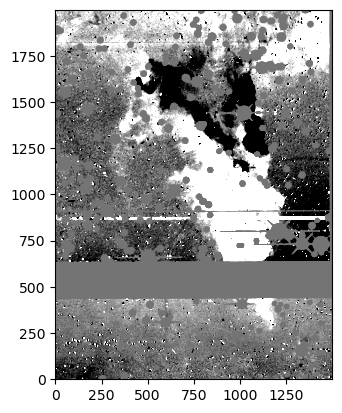

In [215]:

plt.imshow(img[2000:4000, 3000:4500], vmin=vmin, vmax=vmax, origin='lower', cmap='gray',)



(2000.0, 4000.0)

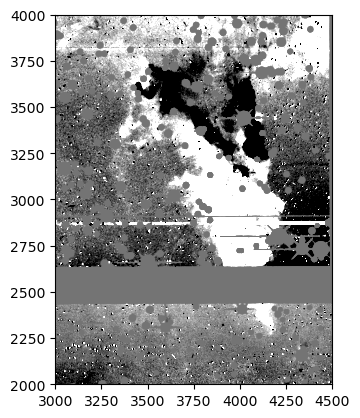

In [218]:
plt.imshow(img, vmin=vmin, vmax=vmax, origin='lower', cmap='gray',)

plt.xlim([3000, 4500])
plt.ylim([2000, 4000])

### make region file

In [46]:

head_lines = [
'# Region file format: DS9 version 4.1\n',
'global color=green dashlist=8 3 width=1 font="helvetica 10 normal roman" select=1 highlite=1 dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1\n',
'fk5\n'
]

with open('region_all.reg', 'w') as file:
    file.writelines(head_lines)

#ra = 161.0157270236892
#dec = -60.35611811582043
#label = 117
## pixel scale 0.27"
#line = f"box({ra}, {dec}, 0.810\", 0.810\", 0) # color=blue  text={{{label}}}\n"



In [47]:
lines = []

for i in dic_df_poly1.keys():
    df = dic_df_poly1[i]
    if len(df)>0:
        x, y = df.iloc[0][['x', 'y']]
        ra, dec = w54.pixel_to_world_values(x, y)

        if (i in IDs_good_fits_poly1) or (i in IDs_comet_poly1):
            color = 'red'
            label = i
        else:
            color = 'green'
            if i%10 !=0:
                label = ''
            else:
                label = i
        
        line = f"box({ra}, {dec}, 0.810\", 0.810\", 0) # color={color}  text={{{label}}}\n"

        lines.append(line)
        


for i in dic_df_57.keys():
    df = dic_df_57[i]
    if len(df)>0:
        x, y = df.iloc[0][['x', 'y']]
        ra, dec = w57.pixel_to_world_values(x, y)

        if (i in IDs_good_fits_57):
            color = 'red'
            label = i
        else:
            color = 'green'
            if i%10 !=0:
                label = ''
            else:
                label = i
            
        
        line = f"box({ra}, {dec}, 0.810\", 0.810\", 0) # color={color}  text={{{label}}}\n"

        lines.append(line)
        

In [48]:
for i in dic_df_poly2.keys():
    df = dic_df_poly2[i]
    if len(df)>0:
        x, y = df.iloc[0][['x', 'y']]
        ra, dec = w54.pixel_to_world_values(x, y)

        if False:
            color = 'red'
            label = i
        else:
            color = 'magenta'
            if i%10 !=0:
                label = ''
            else:
                label = i
        
        line = f"box({ra}, {dec}, 0.810\", 0.810\", 0) # color={color}  text={{{label}}}\n"

        lines.append(line)
        

In [49]:
for i in dic_df_54_Arm.keys():
    df = dic_df_54_Arm[i]
    if len(df)>0:
        x, y = df.iloc[0][['x', 'y']]
        ra, dec = w54.pixel_to_world_values(x, y)
        
        color = 'red'
        label = i
            
        line = f"box({ra}, {dec}, 0.810\", 0.810\", 0) # color={color}  text={{{label}}}\n"
    
        lines.append(line)
    

        


In [51]:
# include Eta Car location
ra = 161.26477
dec = -59.68443
label = 'Eta Car'
color = 'red'
line = f"box({ra}, {dec}, 0.810\", 0.810\", 0) # color={color}  text={{{label}}}\n"


lines.append(line)

In [52]:
with open('region_all.reg', 'a') as file:
    file.writelines(lines)



In [274]:
pwd

'/Users/home/Documents/Research/Eta_Car'

### show example of fitting without convolve

<ErrorbarContainer object of 3 artists>

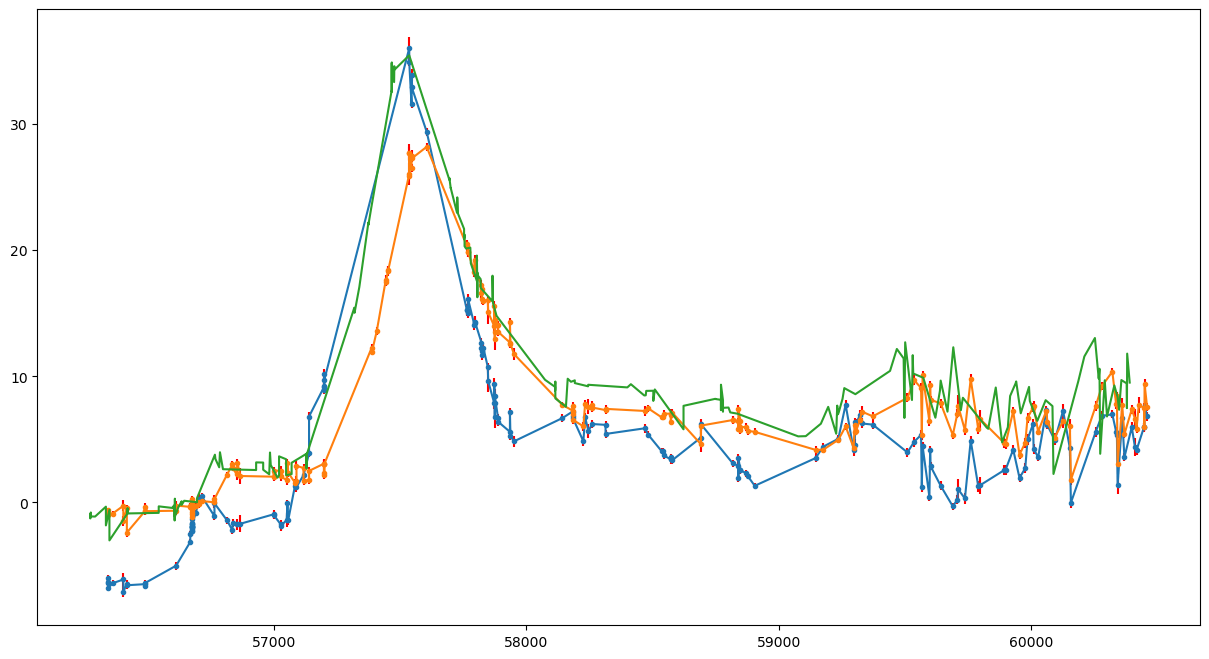

In [226]:
fig = plt.figure(figsize=(15, 8))

ax = fig.add_subplot(1, 1, 1, )##projection=wcs_out)

df = dic_df_poly1[19]
idx = ( df.good ) & (df['fluxADU']<1000)
t1 = df[idx]['mjd'].values
f1 = df[idx]['Jyas2'].values
f1_err = df[idx]['Jyas2_err'].values

ax.errorbar(t1, f1, f1_err, fmt='.-', ecolor='red',)


#------
df = dic_df_poly1[12]
idx = ( df.good ) & (df['fluxADU']<1000)
t2 = df[idx]['mjd'].values
f2 = df[idx]['Jyas2'].values
f2_err = df[idx]['Jyas2_err'].values

ax.errorbar(t2, f2, f2_err, fmt='.-', ecolor='red',)

tshift, a, b = get_tshift_scale_offset(t1, f1, t2, f2)

ax.errorbar(t2-tshift, f2*a,)



### convolve to estimate dust width

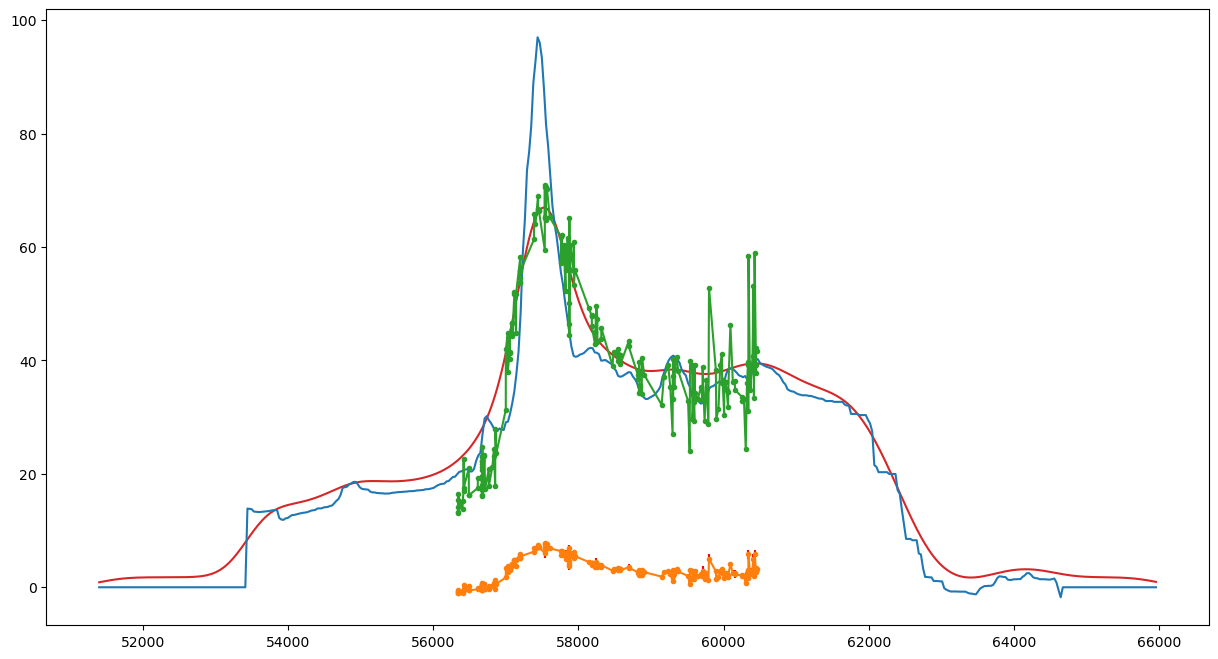

In [247]:

fig = plt.figure(figsize=(15, 8))

ax = fig.add_subplot(1, 1, 1, )##projection=wcs_out)

#df = dic_df_poly1[19]
#idx = ( df.good ) & (df['fluxADU']<1000)
#t1 = df[idx]['mjd'].values
#f1 = df[idx]['Jyas2'].values
#f1_err = df[idx]['Jyas2_err'].values

#ax.errorbar(t1, f1, f1_err, fmt='.-', ecolor='red',)
ax.errorbar(T_model, F_model_i)

df = dic_df_poly1[560]
idx = ( df.good ) & (df['fluxADU']<1000)
t2 = df[idx]['mjd'].values
f2 = df[idx]['Jyas2'].values
f2_err = df[idx]['Jyas2_err'].values

ax.errorbar(t2, f2, f2_err, fmt='.-', ecolor='red',)


tshift, a, b = get_tshift_scale_offset(T_model, F_model_i, t2, f2)


ax.errorbar(t2, f2*a + b, fmt='.-', ecolor='red',)

plt.plot(T_model, convolved_curve)


In [234]:

from scipy.signal import convolve

# Define a Gaussian kernel
def gaussian_kernel(size, sigma):
    x = np.linspace(-size / 2, size / 2, size)
    kernel = np.exp(-x**2 / (2 * sigma**2))
    return kernel / kernel.sum()



In [245]:
# Parameters for the Gaussian kernel
kernel_size = 100
sigma = 10

# Generate the Gaussian kernel
gaussian = gaussian_kernel(kernel_size, sigma)


curve = F_model_i
convolved_curve = convolve(curve-curve.min(), gaussian, mode='same')


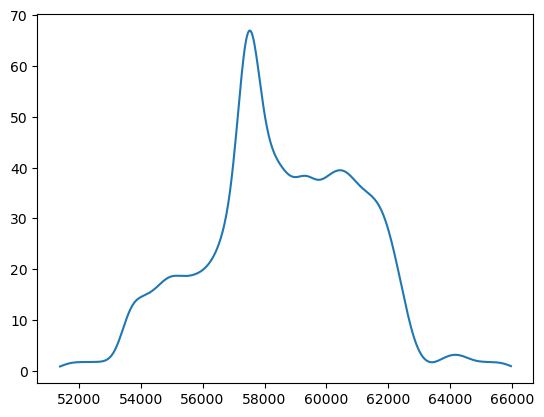

In [246]:
plt.plot(T_model, convolved_curve)

### add patch

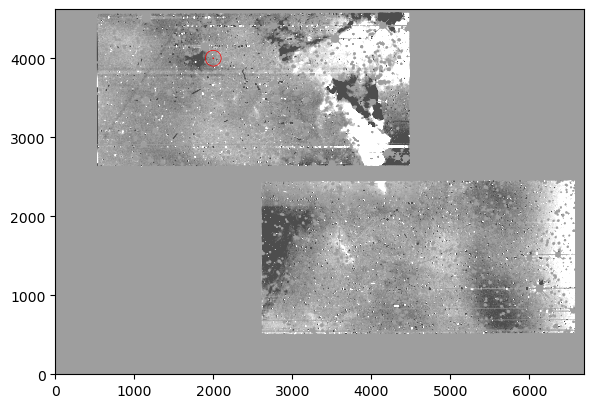

In [110]:
fig

### project to ra/dec

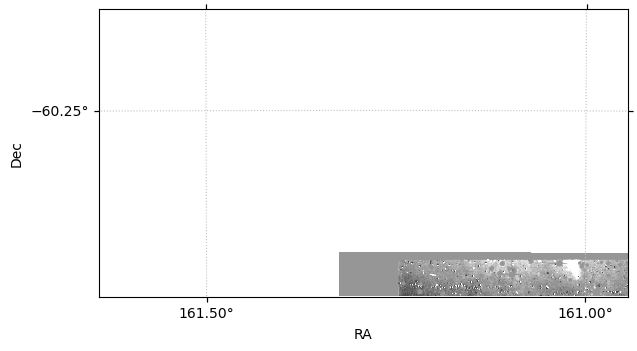

In [18]:

#fig, axs = plt.subplots(1, 2, subplot_kw={'projection':w})

fig = plt.figure(figsize=(15, 8))
ax1 = fig.add_subplot(1, 2, 1, projection=w)

img = combined_data

vmin, vmax = get_vmin_vmax(img)
im = ax1.imshow(img, vmin=vmin, vmax=vmax, 
                cmap='gray', origin='lower', alpha=0.7)
ax1.grid('on', color='silver', ls='dotted')

#cb = fig.colorbar(im, shrink=0.6, location='bottom');

# set coordinates label ticks
lon = ax1.coords[0];
lat = ax1.coords[1];

lon.set_axislabel("RA")
lat.set_axislabel("Dec")

#lon.set_major_formatter("dd:mm")
#lat.set_major_formatter("dd:mm")

lon.set_major_formatter("d.dd")
lat.set_major_formatter("d.dd")


lon.set_ticks(spacing=.5 * u.deg, )
lat.set_ticks(spacing= 15 * u.arcmin)

#  pixel space
#ax2 = fig.add_subplot(1, 2, 2,)
#im = ax2.imshow(img, vmin=vmin, vmax=vmax, 
#                cmap='gray', origin='lower', alpha=0.7);
#ax2.grid('on', color='silver', ls='dotted')

#cb = fig.colorbar(im, shrink=0.6, location='bottom');



